# 01 — Explore EPC Dataset (UseCase4)

**Goal:** Explore the TR EPC dataset built from real Family Steps data and validate the TKG structure.

## What we explore:
1. Dataset structure (activities, families, steps, disciplines)
2. Work permit distribution
3. Project timeline (Gantt by discipline)
4. PRECEDES chain examples
5. Bitemporal rule change validation
6. Neo4j graph verification

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from datetime import datetime, timezone
import warnings
warnings.filterwarnings('ignore')

# Paths — auto-detect Linux vs Windows
if Path('/home/obiaggi').exists():
    DATA_DIR = Path('/home/obiaggi/TKG_Thesis/data/UseCase4')
    EXP_DIR  = Path('/home/obiaggi/TKG_Thesis/experiments/UseCase4')
else:
    DATA_DIR = Path('../../data/UseCase4')
    EXP_DIR  = Path('../../experiments/UseCase4')

EXP_DIR.mkdir(parents=True, exist_ok=True)

with open(DATA_DIR / 'epc_dataset_real.json') as f:
    d = json.load(f)

df_steps = pd.DataFrame(d['steps'])
df_acts  = pd.DataFrame(d['activities'])
df_acts['discipline'] = df_acts['id'].str.split('.').str[0]

print(f'✅ Dataset loaded')
print(f'   Activities:  {len(d["activities"])}')
print(f'   Steps:       {len(d["steps"])}')
print(f'   Workers:     {len(d["workers"])}')
print(f'   WorkPermits: {len(d["work_permits"])}')
print(f'   Certs:       {len(d["certifications"])}')

✅ Dataset loaded
   Activities:  276
   Steps:       1518
   Workers:     50
   WorkPermits: 8
   Certs:       33


/home/obiaggi/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Dataset Structure

In [2]:
print('=== Activities per Discipline ===')
disc_counts = df_acts.groupby('discipline').size().sort_values(ascending=False)
print(disc_counts.to_string())

print('\n=== Top 10 Activities by Number of Steps ===')
step_counts = df_steps.groupby('activity_id').size().sort_values(ascending=False)
print(step_counts.head(10).to_string())

print('\n=== Sample Activity — Heat Exchangers (ME.HE1) ===')
he = df_steps[df_steps['activity_id']=='ME.HE1'].sort_values('order')
print(he[['order','name','weight_pct','permit_type','valid_from']].to_string())

=== Activities per Discipline ===
discipline
CI    95
ME    30
CO    22
IN    20
EL    15
PE    15
BU    14
MD    12
PI    11
PR    11
ST     9
SP     7
PA     5
IS     4
HV     2
FP     2
PL     2

=== Top 10 Activities by Number of Steps ===
activity_id
BU.BR.AR    53
ME.CT       19
BU.BR.CS    19
BU.BR.FO    18
BU.TR.CS    15
CI.TF1      14
ME.TK3      14
BU.PC.AR    13
CI.DM2      13
CI.PS1      12

=== Sample Activity — Heat Exchangers (ME.HE1) ===
     order                            name  weight_pct   permit_type                 valid_from
588      1  Base Preparation & Shim Plates         5.0  general_work  2024-06-28T00:00:00+00:00
589      2              Equipment erection        85.0       lifting  2024-09-30T00:00:00+00:00
590      3                       Alignment         5.0  general_work  2024-12-29T00:00:00+00:00
591      4               QA\QC Certificate         5.0  general_work  2025-03-29T00:00:00+00:00


## 2. Work Permit Distribution

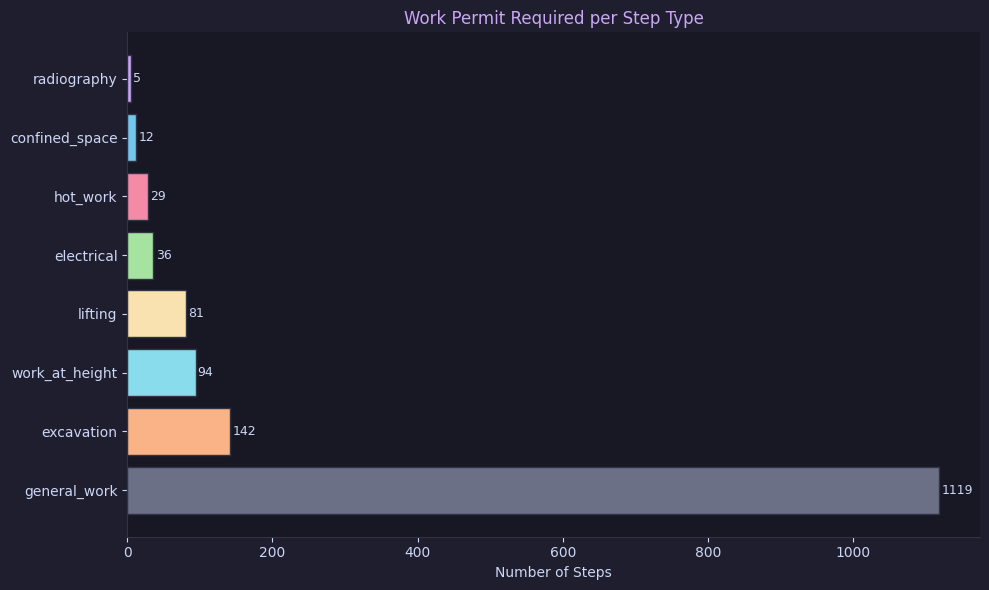

✅ Saved


In [3]:
COLORS = {
    'hot_work':'#f38ba8','excavation':'#fab387','lifting':'#f9e2af',
    'electrical':'#a6e3a1','confined_space':'#74c7ec','radiography':'#cba6f7',
    'work_at_height':'#89dceb','general_work':'#6c7086',
}
permit_counts = df_steps['permit_type'].value_counts()
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#181825')
colors = [COLORS.get(p,'#cdd6f4') for p in permit_counts.index]
bars = ax.barh(permit_counts.index, permit_counts.values, color=colors, edgecolor='#313244')
for bar, val in zip(bars, permit_counts.values):
    ax.text(bar.get_width()+3, bar.get_y()+bar.get_height()/2, str(val), va='center', color='#cdd6f4', fontsize=9)
ax.set_xlabel('Number of Steps', color='#cdd6f4')
ax.set_title('Work Permit Required per Step Type', color='#cba6f7', fontsize=12)
ax.tick_params(colors='#cdd6f4')
for s in ['top','right']: ax.spines[s].set_visible(False)
for s in ['bottom','left']: ax.spines[s].set_color('#313244')
plt.tight_layout()
plt.savefig(EXP_DIR/'1_permit_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved')

## 3. Project Gantt

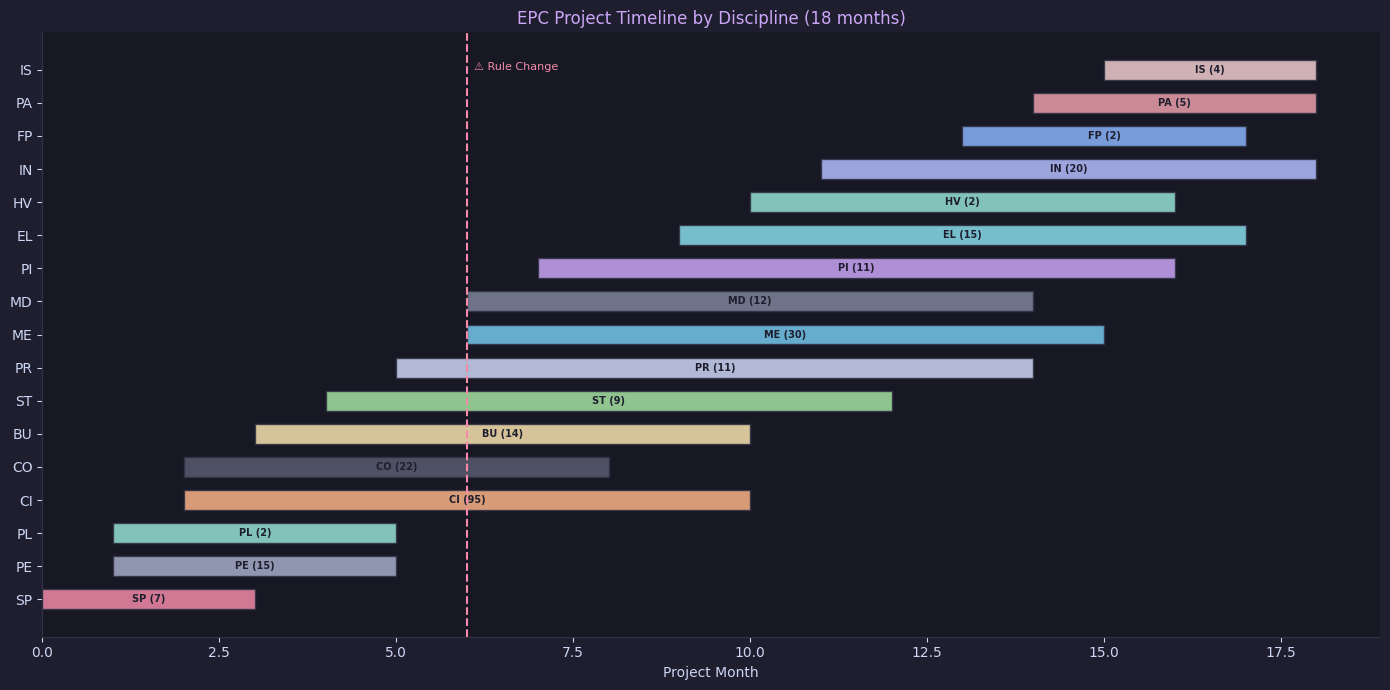

✅ Saved


In [4]:
TIMELINE = {'SP':(0,3),'PE':(1,5),'PL':(1,5),'CI':(2,10),'CO':(2,8),
    'BU':(3,10),'ST':(4,12),'ME':(6,15),'MD':(6,14),'PI':(7,16),
    'EL':(9,17),'IN':(11,18),'PR':(5,14),'PA':(14,18),'IS':(15,18),
    'FP':(13,17),'HV':(10,16)}
DCOL = {'SP':'#f38ba8','CI':'#fab387','BU':'#f9e2af','ST':'#a6e3a1','ME':'#74c7ec',
    'PI':'#cba6f7','EL':'#89dceb','IN':'#b4befe','PR':'#cdd6f4','PE':'#a6adc8',
    'CO':'#585b70','MD':'#7f849c','PA':'#eba0ac','IS':'#f2cdcd','FP':'#89b4fa',
    'HV':'#94e2d5','PL':'#94e2d5'}
disc_order = sorted(TIMELINE.keys(), key=lambda x: TIMELINE[x][0])
n_acts = {dd: len(df_acts[df_acts['discipline']==dd]) for dd in disc_order}
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#1e1e2e'); ax.set_facecolor('#181825')
for i, disc in enumerate(disc_order):
    s, e = TIMELINE[disc]
    ax.barh(i, e-s, left=s, height=0.6, color=DCOL.get(disc,'#cdd6f4'), alpha=0.85, edgecolor='#313244')
    ax.text(s+(e-s)/2, i, f"{disc} ({n_acts.get(disc,0)})", ha='center', va='center', color='#1e1e2e', fontsize=7, fontweight='bold')
ax.axvline(x=6, color='#f38ba8', linestyle='--', linewidth=1.5)
ax.text(6.1, len(disc_order)-1, '⚠ Rule Change', color='#f38ba8', fontsize=8)
ax.set_yticks(range(len(disc_order))); ax.set_yticklabels(disc_order, color='#cdd6f4')
ax.set_xlabel('Project Month', color='#cdd6f4')
ax.set_title('EPC Project Timeline by Discipline (18 months)', color='#cba6f7', fontsize=12)
ax.tick_params(colors='#cdd6f4')
for s in ['top','right']: ax.spines[s].set_visible(False)
for s in ['bottom','left']: ax.spines[s].set_color('#313244')
plt.tight_layout()
plt.savefig(EXP_DIR/'2_project_gantt.png', dpi=150, bbox_inches='tight')
plt.show(); print('✅ Saved')

## 4. PRECEDES Chain

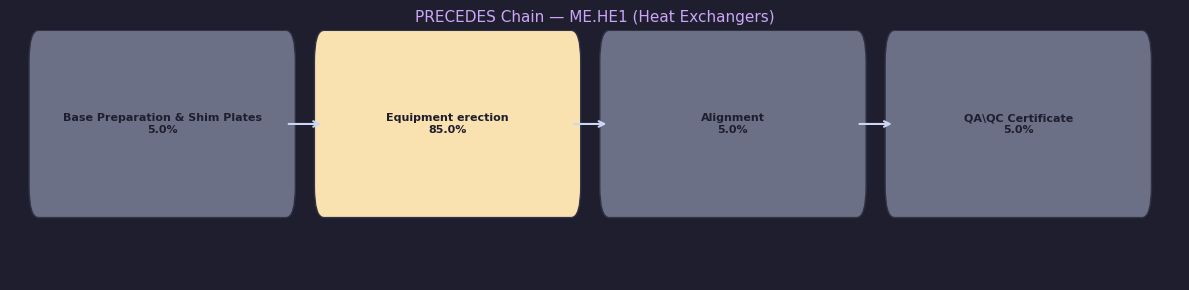

✅ Saved


In [5]:
chain = df_steps[df_steps['activity_id']=='ME.HE1'].sort_values('order')
fig, ax = plt.subplots(figsize=(12, 3))
fig.patch.set_facecolor('#1e1e2e'); ax.set_facecolor('#181825'); ax.axis('off')
for i, (_, row) in enumerate(chain.iterrows()):
    color = COLORS.get(row['permit_type'],'#cdd6f4')
    x = i * 3
    ax.add_patch(mpatches.FancyBboxPatch((x,0.3),2.6,0.4,boxstyle='round,pad=0.1',facecolor=color,edgecolor='#313244'))
    ax.text(x+1.3,0.5,f"{row['name']}\n{row['weight_pct']}%",ha='center',va='center',color='#1e1e2e',fontsize=8,fontweight='bold')
    ax.text(x+1.3,0.22,row['permit_type'].replace('_',' '),ha='center',va='center',color=color,fontsize=7)
    if i < len(chain)-1:
        ax.annotate('',xy=(x+3.0,0.5),xytext=(x+2.6,0.5),arrowprops=dict(arrowstyle='->',color='#cdd6f4',lw=1.5))
ax.set_xlim(-0.3,len(chain)*3); ax.set_ylim(0,0.8)
ax.set_title('PRECEDES Chain — ME.HE1 (Heat Exchangers)',color='#cba6f7',fontsize=11)
plt.tight_layout()
plt.savefig(EXP_DIR/'3_precedes_chain.png', dpi=150, bbox_inches='tight')
plt.show(); print('✅ Saved')

## 5. Bitemporal Query Tests

In [6]:
print('='*60)
print('TEMPORAL QUERY TESTS')
print('='*60)
query_date = '2024-07-01'
hot_steps = [s for s in d['steps'] if s['permit_type']=='hot_work' and s['valid_from']<=query_date<=s['valid_to']]
print(f'\nQ1: Hot work steps active on {query_date}: {len(hot_steps)}')
for s in hot_steps[:5]: print(f'  - {s["name"]} ({s["activity_id"]})')
rule_change = '2024-06-29'
missing = [w['id'] for w in d['workers'] if not any(c['cert']=='Advanced Fire Watch' for c in w['certifications'])]
print(f'\nQ2: Workers missing new cert after rule change: {len(missing)}')
ue = d['update_events'][0]
print(f'\nQ3: Bitemporal audit')
print(f'  Before {rule_change}: Hot Work Safety, Fire Watch, Welding Cert')
print(f'  After  {rule_change}: + Advanced Fire Watch')
print(f'  Rule change valid_from: {ue["valid_from"][:10]}')
print(f'  Recorded in system:     {ue["tx_time"][:10]}')
print('\n✅ All temporal queries validated!')

TEMPORAL QUERY TESTS

Q1: Hot work steps active on 2024-07-01: 3
  - Cutting/Beveling & Alignment (MD.PI.HU)
  - Welding (PE.UG)
  - Welding (CI.UP)

Q2: Workers missing new cert after rule change: 50

Q3: Bitemporal audit
  Before 2024-06-29: Hot Work Safety, Fire Watch, Welding Cert
  After  2024-06-29: + Advanced Fire Watch
  Rule change valid_from: 2024-06-29
  Recorded in system:     2026-04-21

✅ All temporal queries validated!


## 6. Neo4j Graph Verification

In [7]:
from neo4j import GraphDatabase
try:
    driver = GraphDatabase.driver('bolt://localhost:7687', auth=('neo4j','your_password'))
    with driver.session() as session:
        for label in ['Project','Family','Activity','Step','WorkPermit','Certification','Worker']:
            c = session.run(f'MATCH (n:{label}) RETURN count(n) AS c').single()['c']
            print(f'  {label:<15}: {c:,}')
        for rel in ['INCLUDES','BELONGS_TO','HAS_STEP','PRECEDES','REQUIRES_PERMIT','REQUIRES_CERT','HAS_CERT']:
            c = session.run(f'MATCH ()-[r:{rel}]->() RETURN count(r) AS c').single()['c']
            print(f'  :{rel:<20}: {c:,}')
    driver.close()
    print('\n✅ Neo4j verified!')
except Exception as e:
    print(f'⚠️  Neo4j not available: {e}\n   Run import_graph_real.py first')

  Project        : 1
  Family         : 276
  Activity       : 276
  Step           : 1,419
  WorkPermit     : 8
  Certification  : 33
  Worker         : 50
  :INCLUDES            : 276
  :BELONGS_TO          : 276
  :HAS_STEP            : 1,477
  :PRECEDES            : 1,208
  :REQUIRES_PERMIT     : 1,436
  :REQUIRES_CERT       : 24
  :HAS_CERT            : 248

✅ Neo4j verified!
